In [4]:
import sys

from matplotlib import rcParams
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

# defining figure size
FIGSIZE = (3, 3)
rcParams["figure.figsize"] = FIGSIZE


In [5]:
# H5AD_PATH = "../project_folder/gdrive/ds_HID01_logicle_100k_UMAP_ann.h5ad"
H5AD_PATH = "../project_folder/gdrive/ds_HID01_logicle_100k_UMAP_ann.h5ad"
adata = sc.read_h5ad(H5AD_PATH)
adata


AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'positives', 'raw'
    

In [12]:
OBSM_KEY = "X_repr"
channel2cofactor = {
    'CD49f':3_000,
    'CD235a':3_000,
    'CD34':5_000,
    'CD19':2_500,
    'CD49c':5_000,
    'CD41a':2_500,
    'CD117':3_000,
    'CD38':2_500,
    'HLADR':3_000,
    'EPCR':5_000,
    'CD135':3_000,
    'CD56':1_000,
    'CD15':3_000,
    'CD123':3_000,
    'CD45':1_500,
    'CD90':3_000,
    'CD45RA':10_000,
    'CD10':5_000,
    'CD14':3_000,
    'CD7': 500,
    'CD16': 750,
}

X_channels = adata.layers["raw"]
cofactors = np.zeros((1, X_channels.shape[1]))
for channel, cofactor in channel2cofactor.items():
    idx = adata.var_names.tolist().index(channel)
    cofactor = 3000
    cofactors[0, idx] = cofactor
X_channels = np.arcsinh(X_channels / cofactors)
adata

AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'positives', 'raw'
    

In [15]:
def plot_marginals(X_real, X_gen=None, col_names=None, title=""):
   
    # sanity checks
    n_channels = X_real.shape[1]
    if X_gen is not None:
        assert X_gen.shape[1] == n_channels
    if col_names is not None:
        assert len(col_names) == n_channels

    # create subplots (1 row, n_channels columns)
    fig, ax = plt.subplots(1, n_channels, figsize=(45, 5))
    fig.suptitle(f"{title}", fontsize=16)

    # loop over channels
    for i in range(n_channels):
        ax[i].grid(True)
        sns.kdeplot(X_real[:, i], ax=ax[i], color="green", label="real")
        if X_gen is not None:
            sns.kdeplot(X_gen[:, i], ax=ax[i], color="red", label="gen")
        ax[i].legend()
        if col_names is not None:
            ax[i].set_title(col_names[i])

    fig.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle
    # fig.show()
    return fig


In [ ]:
plot_marginals(X_channels, col_names=adata.var_names)

In [13]:
mini_adata = sc.AnnData(X=X_channels)
sc.pp.pca(mini_adata)
sc.pp.neighbors(mini_adata)
sc.tl.umap(mini_adata)

/home/icb/lorenzo.consoli/miniconda3/envs/cellflow-nvidia12/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:245: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  Version(ad.__version__) < Version("0.9")
/home/icb/lorenzo.consoli/miniconda3/envs/cellflow-nvidia12/lib/python3.12/site-packages/scanpy/neighbors/__init__.py:430: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if "X_diffmap" in adata.obsm_keys():


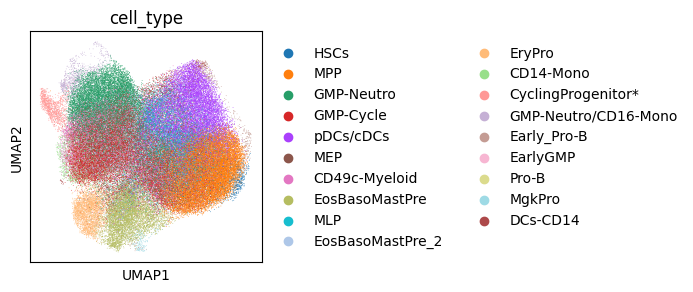

In [11]:
mini_adata.obs = adata.obs
sc.pl.embedding(mini_adata, "umap", color="cell_type")